# Дообучение RuBERT-base

RuBERT-base получает условие кейса и решение одной последовательностью и предсказывает пять оценок. Из-за размера модели сравниваются два режима: обучение выходного слоя и разморозка последнего transformer-слоя.

In [1]:
from pathlib import Path
import copy
import json
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, DataCollatorWithPadding, get_linear_schedule_with_warmup

SEED = 1537
MODEL_NAME = 'ai-forever/ruBert-base'
MAX_LENGTH = 512
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
BAD_THRESHOLD = 60.0
Y_cols = ['score_factchecking', 'score_originality', 'score_effectiveness', 'score_logic', 'score_completeness']
TOTAL_SCORE_WEIGHTS = {'score_factchecking': 0.20, 'score_originality': 0.25, 'score_effectiveness': 0.25, 'score_logic': 0.15, 'score_completeness': 0.15}
TOTAL_WEIGHT_VECTOR = np.array([TOTAL_SCORE_WEIGHTS[column] for column in Y_cols])
DATA_DIR = Path('data/solution_evaluation/model')
ARTIFACTS_DIR = Path('../artifacts')
TRANSFORMER_DIR = ARTIFACTS_DIR / 'rubert_base_partial_multitask'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = DEVICE.type == 'cuda'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE

device(type='cpu')

## Загрузка данных

In [2]:
train = pd.read_csv(DATA_DIR / 'train_real_synthetic.csv')
val_real = pd.read_csv(DATA_DIR / 'val_real.csv')
stress_val = pd.read_csv(DATA_DIR / 'stress_val.csv')
test_real = pd.read_csv(DATA_DIR / 'test_real.csv')
stress_test = pd.read_csv(DATA_DIR / 'stress_test.csv')
external_test = pd.read_csv(DATA_DIR / 'external_low_quality_test.csv')

assert {'real', 'synthetic'}.issubset(set(train['origin']))
assert set(train['case_id']).isdisjoint(val_real['case_id'])
assert set(train['case_id']).isdisjoint(test_real['case_id'])
assert set(val_real['case_id']).isdisjoint(test_real['case_id'])
assert set(stress_val['case_id']).issubset(set(val_real['case_id']))
assert set(stress_test['case_id']).issubset(set(test_real['case_id']))
assert 30 <= len(external_test) <= 50

frames = {
    'TRAIN': train, 'REAL_VAL': val_real, 'STRESS_VAL': stress_val,
    'REAL_TEST': test_real, 'STRESS_TEST': stress_test,
    'EXTERNAL_LOW_QUALITY_TEST': external_test,
}
{name: frame.shape for name, frame in frames.items()}

{'TRAIN': (453, 14),
 'REAL_VAL': (67, 12),
 'STRESS_VAL': (18, 14),
 'REAL_TEST': (62, 12),
 'STRESS_TEST': (42, 14),
 'EXTERNAL_LOW_QUALITY_TEST': (30, 17)}

## Подготовка текста и модель

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
assert tokenizer.model_max_length >= MAX_LENGTH

class CaseSolutionDataset(Dataset):
    def __init__(self, frame, tokenizer, max_length, training=False):
        frame = frame.reset_index(drop=True)
        self.encodings = tokenizer(
            frame['case_text'].fillna('').astype(str).tolist(),
            frame['solution_text'].fillna('').astype(str).tolist(),
            truncation='longest_first', max_length=max_length, padding=False,
        )
        self.labels = frame[Y_cols].to_numpy(dtype='float32') / 100.0
        self.sample_weights = np.where(
            training & frame.get('origin', pd.Series('', index=frame.index)).eq('real'), 2.0, 1.0
        ).astype('float32')

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        encoded = {key: values[index] for key, values in self.encodings.items()}
        encoded['labels'] = self.labels[index].tolist()
        encoded['sample_weight'] = float(self.sample_weights[index])
        return encoded


class RuBertMultiTaskRegressor(nn.Module):
    def __init__(self, model_name, output_count):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name, low_cpu_mem_usage=True)
        self.dropout = nn.Dropout(0.2)
        self.regression_head = nn.Linear(self.encoder.config.hidden_size, output_count)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        encoder_output = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids,
        )
        pooled = encoder_output.last_hidden_state[:, 0]
        return torch.sigmoid(self.regression_head(self.dropout(pooled)))

config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [4]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')
datasets = {
    name: CaseSolutionDataset(frame, tokenizer, MAX_LENGTH, training=name == 'TRAIN')
    for name, frame in frames.items()
}
loaders = {
    name: DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=name == 'TRAIN',
        collate_fn=data_collator, num_workers=0, pin_memory=torch.cuda.is_available(),
    )
    for name, dataset in datasets.items()
}
{name: len(loader) for name, loader in loaders.items()}

{'TRAIN': 453,
 'REAL_VAL': 67,
 'STRESS_VAL': 18,
 'REAL_TEST': 62,
 'STRESS_TEST': 42,
 'EXTERNAL_LOW_QUALITY_TEST': 30}

## Режимы обучения

В режиме FROZEN обучается выходной слой. PARTIAL начинает с его весов и дополнительно обучает последний слой RuBERT. Накопление градиента позволяет использовать небольшой физический batch

In [5]:
MODE_CONFIGS = {
    'FROZEN': {'epochs': 6, 'encoder_lr': 0.0, 'head_lr': 3e-4},
    'PARTIAL': {'epochs': 4, 'encoder_lr': 5e-6, 'head_lr': 1e-4},
}
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_MIN_DELTA = 0.01
TRANSFORMER_DIR.mkdir(parents=True, exist_ok=True)
mode_checkpoint_paths = {}
mode_best_scores = {}
training_history_rows = []
frozen_head_state = None

for mode_name, mode_config in MODE_CONFIGS.items():
    model = RuBertMultiTaskRegressor(MODEL_NAME, len(Y_cols)).to(DEVICE)
    if mode_name != 'FROZEN':
        model.regression_head.load_state_dict(frozen_head_state)

    for parameter in model.encoder.parameters():
        parameter.requires_grad = False
    if mode_name == 'PARTIAL':
        for parameter in model.encoder.encoder.layer[-1].parameters():
            parameter.requires_grad = True
    if mode_name == 'PARTIAL':
        model.encoder.gradient_checkpointing_enable()
        model.encoder.enable_input_require_grads()

    optimizer_groups = [{'params': model.regression_head.parameters(), 'lr': mode_config['head_lr']}]
    encoder_parameters = [parameter for parameter in model.encoder.parameters() if parameter.requires_grad]
    if encoder_parameters:
        optimizer_groups.append({'params': encoder_parameters, 'lr': mode_config['encoder_lr']})
    optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=0.01)
    total_steps = mode_config['epochs'] * int(np.ceil(len(loaders['TRAIN']) / GRADIENT_ACCUMULATION_STEPS))
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * 0.1), total_steps)
    best_selection_score = np.inf
    best_checkpoint_path = TRANSFORMER_DIR / f'{mode_name.lower()}_best_state.pt'
    epochs_without_improvement = 0
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    for epoch in range(1, mode_config['epochs'] + 1):
        model.train()
        if mode_name == 'FROZEN':
            model.encoder.eval()
        train_losses = []
        optimizer.zero_grad(set_to_none=True)
        for batch_index, batch in enumerate(tqdm(loaders['TRAIN'], desc=f'{mode_name} epoch {epoch}', leave=False), start=1):
            labels = batch.pop('labels').to(DEVICE).float()
            sample_weight = batch.pop('sample_weight').to(DEVICE).float()
            inputs = {key: value.to(DEVICE) for key, value in batch.items()}
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
                predictions = model(**inputs)
                sample_losses = nn.functional.smooth_l1_loss(predictions, labels, reduction='none').mean(dim=1)
                loss = (sample_losses * sample_weight).sum() / sample_weight.sum()
            scaler.scale(loss / GRADIENT_ACCUMULATION_STEPS).backward()
            if batch_index % GRADIENT_ACCUMULATION_STEPS == 0 or batch_index == len(loaders['TRAIN']):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
            train_losses.append(loss.item())

        validation_results = {}
        model.eval()
        for dataset_name in ['REAL_VAL', 'STRESS_VAL']:
            prediction_batches = []
            label_batches = []
            with torch.no_grad():
                for batch in loaders[dataset_name]:
                    labels = batch.pop('labels').numpy() * 100.0
                    batch.pop('sample_weight')
                    inputs = {key: value.to(DEVICE) for key, value in batch.items()}
                    with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
                        batch_predictions = model(**inputs)
                    prediction_batches.append(batch_predictions.float().cpu().numpy() * 100.0)
                    label_batches.append(labels)
            dataset_predictions = np.vstack(prediction_batches)
            dataset_targets = np.vstack(label_batches)
            predicted_total = dataset_predictions @ TOTAL_WEIGHT_VECTOR
            target_total = dataset_targets @ TOTAL_WEIGHT_VECTOR
            validation_results[dataset_name] = {
                'total_MAE': mean_absolute_error(target_total, predicted_total),
                'bad_recall': ((target_total < BAD_THRESHOLD) & (predicted_total < BAD_THRESHOLD)).sum() / (target_total < BAD_THRESHOLD).sum() if (target_total < BAD_THRESHOLD).sum() else np.nan,
            }

        selection_score = 0.6 * validation_results['REAL_VAL']['total_MAE'] + 0.4 * validation_results['STRESS_VAL']['total_MAE']
        training_history_rows.append({
            'mode': mode_name, 'epoch': epoch, 'train_loss': np.mean(train_losses),
            'real_val_MAE': validation_results['REAL_VAL']['total_MAE'],
            'stress_val_MAE': validation_results['STRESS_VAL']['total_MAE'],
            'stress_bad_recall': validation_results['STRESS_VAL']['bad_recall'],
            'selection_score': selection_score,
        })
        if selection_score < best_selection_score - EARLY_STOPPING_MIN_DELTA:
            best_selection_score = selection_score
            if mode_name == 'FROZEN':
                frozen_head_state = copy.deepcopy({key: value.detach().cpu() for key, value in model.regression_head.state_dict().items()})
                torch.save({'regression_head': frozen_head_state}, best_checkpoint_path)
            else:
                checkpoint_state = {key: value.detach().cpu() for key, value in model.state_dict().items()}
                torch.save(checkpoint_state, best_checkpoint_path)
                del checkpoint_state
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            break

    mode_checkpoint_paths[mode_name] = best_checkpoint_path
    mode_best_scores[mode_name] = best_selection_score
    del model, optimizer, scheduler, scaler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

training_history_df = pd.DataFrame(training_history_rows).round(5)
training_history_df

pytorch_model.bin:   0%|          | 0.00/716M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/716M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

FROZEN epoch 1:   0%|          | 0/453 [00:00<?, ?it/s]

FROZEN epoch 2:   0%|          | 0/453 [00:00<?, ?it/s]

...

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


PARTIAL epoch 2:   0%|          | 0/453 [00:00<?, ?it/s]

PARTIAL epoch 3:   0%|          | 0/453 [00:00<?, ?it/s]

PARTIAL epoch 4:   0%|          | 0/453 [00:00<?, ?it/s]

,mode,epoch,train_loss,real_val_MAE,stress_val_MAE,stress_bad_recall,selection_score
0,FROZEN,1,0.02523,5.71529,15.74627,0.00000,9.72768
1,FROZEN,2,0.01425,4.90907,14.52418,0.11111,8.75511
2,FROZEN,3,0.01330,4.53771,14.04519,0.55556,8.34070
3,FROZEN,4,0.01239,4.01764,13.78032,0.66667,7.92271
4,FROZEN,5,0.01228,4.35738,13.62294,0.66667,8.06360
5,FROZEN,6,0.01201,4.42356,13.55856,0.66667,8.07756
6,PARTIAL,1,0.01287,3.87727,13.50471,0.66667,7.72825
7,PARTIAL,2,0.01209,4.04315,13.23088,0.66667,7.71824
8,PARTIAL,3,0.01183,4.05468,13.04606,0.77778,7.65123
9,PARTIAL,4,0.01189,4.07780,12.97863,0.88889,7.63813


## Сравнение режимов

In [6]:
mode_selection_df = (
    training_history_df.sort_values('selection_score')
    .groupby('mode', as_index=False)
    .first()
    .sort_values('selection_score')
    .reset_index(drop=True)
)
selected_mode = mode_selection_df.iloc[0]['mode']
selected_model = RuBertMultiTaskRegressor(MODEL_NAME, len(Y_cols)).to(DEVICE)
selected_checkpoint = torch.load(mode_checkpoint_paths[selected_mode], map_location='cpu', weights_only=False)
if selected_mode == 'FROZEN':
    selected_model.regression_head.load_state_dict(selected_checkpoint['regression_head'])
else:
    selected_model.load_state_dict(selected_checkpoint)
del selected_checkpoint
selected_model.eval()
mode_selection_df

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,mode,epoch,train_loss,real_val_MAE,stress_val_MAE,stress_bad_recall,selection_score
0,PARTIAL,4,0.01189,4.07780,12.97863,0.88889,7.63813
1,FROZEN,4,0.01239,4.01764,13.78032,0.66667,7.92271


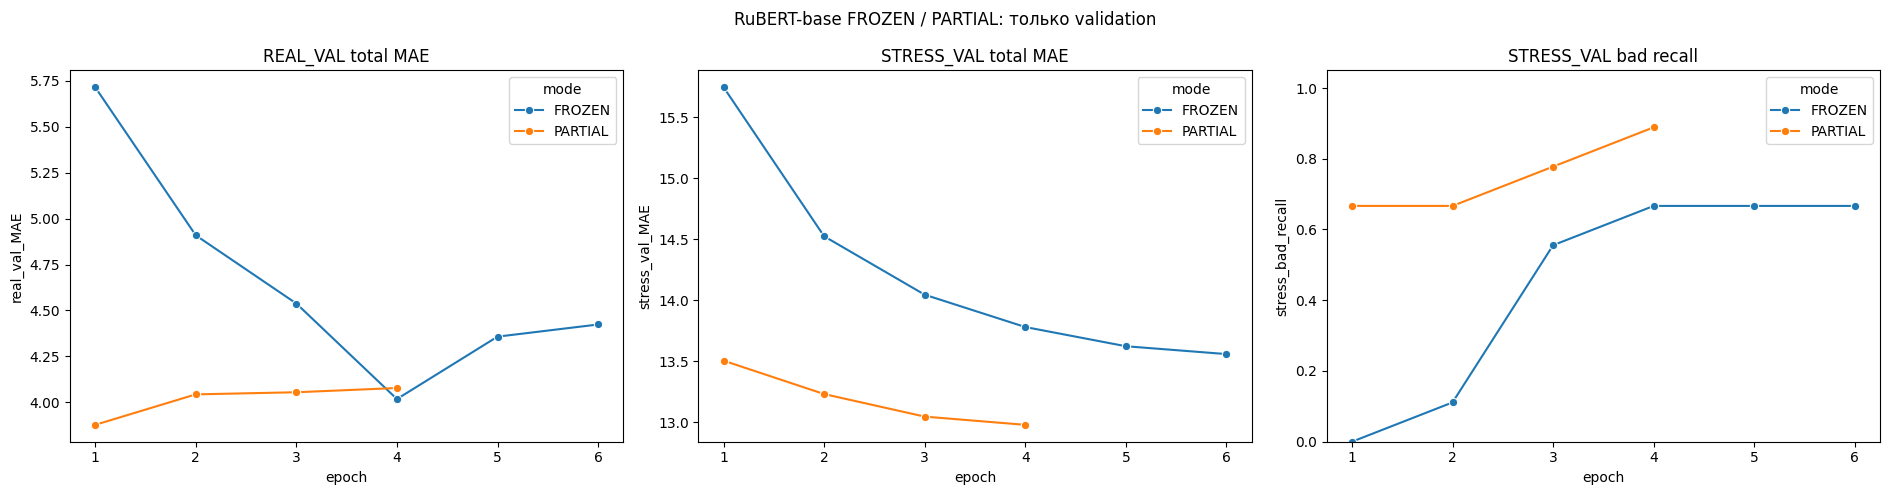

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.lineplot(data=training_history_df, x='epoch', y='real_val_MAE', hue='mode', marker='o', ax=axes[0])
axes[0].set_title('REAL_VAL total MAE')
sns.lineplot(data=training_history_df, x='epoch', y='stress_val_MAE', hue='mode', marker='o', ax=axes[1])
axes[1].set_title('STRESS_VAL total MAE')
sns.lineplot(data=training_history_df, x='epoch', y='stress_bad_recall', hue='mode', marker='o', ax=axes[2])
axes[2].set_ylim(0, 1.05)
axes[2].set_title('STRESS_VAL bad recall')
fig.suptitle('RuBERT-base FROZEN / PARTIAL: только validation')
fig.tight_layout()
plt.show()

## Оценка выбранной модели

In [8]:
transformer_metric_rows = []
transformer_prediction_cache = {}
for dataset_name in ['REAL_TEST', 'STRESS_TEST', 'EXTERNAL_LOW_QUALITY_TEST']:
    prediction_batches = []
    label_batches = []
    with torch.no_grad():
        for batch in loaders[dataset_name]:
            labels = batch.pop('labels').numpy() * 100.0
            batch.pop('sample_weight')
            inputs = {key: value.to(DEVICE) for key, value in batch.items()}
            prediction_batches.append(selected_model(**inputs).cpu().numpy() * 100.0)
            label_batches.append(labels)
    predictions = pd.DataFrame(np.vstack(prediction_batches), columns=Y_cols)
    targets = pd.DataFrame(np.vstack(label_batches), columns=Y_cols)
    predictions['score_total'] = predictions[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    targets['score_total'] = targets[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    transformer_prediction_cache[dataset_name] = predictions
    true_bad = targets['score_total'] < BAD_THRESHOLD
    predicted_bad = predictions['score_total'] < BAD_THRESHOLD
    bad_recall = (true_bad & predicted_bad).sum() / true_bad.sum() if true_bad.sum() else np.nan
    for score in [*Y_cols, 'score_total']:
        transformer_metric_rows.append({
            'model': f'RUBERT_BASE_{selected_mode}', 'dataset': dataset_name, 'score': score,
            'MSE': mean_squared_error(targets[score], predictions[score]),
            'MAE': mean_absolute_error(targets[score], predictions[score]),
            'R2': r2_score(targets[score], predictions[score]),
            'bad_recall': bad_recall if score == 'score_total' else np.nan,
        })
transformer_metrics_df = pd.DataFrame(transformer_metric_rows).round(4)
transformer_metrics_df

,model,dataset,score,MSE,MAE,R2,bad_recall
0,RUBERT_BASE_PARTIAL,REAL_TEST,score_factchecking,42.8615,5.6512,-1.4804,NaN
1,RUBERT_BASE_PARTIAL,REAL_TEST,score_originality,99.4868,8.5169,-0.0549,NaN
2,RUBERT_BASE_PARTIAL,REAL_TEST,score_effectiveness,68.3251,6.7107,0.3610,NaN
3,RUBERT_BASE_PARTIAL,REAL_TEST,score_logic,27.7912,4.0397,-0.0821,NaN
4,RUBERT_BASE_PARTIAL,REAL_TEST,score_completeness,62.4527,6.3848,0.3317,NaN
5,RUBERT_BASE_PARTIAL,REAL_TEST,score_total,14.8179,3.0507,0.1110,NaN
6,RUBERT_BASE_PARTIAL,STRESS_TEST,score_factchecking,1016.2067,23.2521,-0.0855,NaN
7,RUBERT_BASE_PARTIAL,STRESS_TEST,score_originality,190.3590,11.4282,0.0500,NaN
8,RUBERT_BASE_PARTIAL,STRESS_TEST,score_effectiveness,625.3187,22.9048,0.2400,NaN
9,RUBERT_BASE_PARTIAL,STRESS_TEST,score_logic,478.3229,18.7527,0.2599,NaN


## Сохранение модели

In [9]:
TRANSFORMER_DIR.mkdir(parents=True, exist_ok=True)
tokenizer.save_pretrained(TRANSFORMER_DIR / 'tokenizer')
torch.save({
    'state_dict': {key: value.detach().cpu() for key, value in selected_model.state_dict().items()},
    'model_name': MODEL_NAME, 'selected_mode': selected_mode,
    'max_length': MAX_LENGTH, 'target_columns': Y_cols,
    'total_score_weights': TOTAL_SCORE_WEIGHTS, 'bad_threshold': BAD_THRESHOLD,
    'split_seed': SEED, 'training_regime': 'ALL_SYNTH_WEIGHTED',
    'sample_weights': {'real': 2.0, 'synthetic': 1.0},
    'selection_weights': {'real': 0.6, 'stress': 0.4},
}, TRANSFORMER_DIR / 'rubert_base_partial_multitask.pt')
training_history_df.to_csv(TRANSFORMER_DIR / 'training_history.csv', index=False)
mode_selection_df.to_csv(TRANSFORMER_DIR / 'mode_selection.csv', index=False)
transformer_metrics_df.to_csv(TRANSFORMER_DIR / 'metrics.csv', index=False)

saved_checkpoint = torch.load(TRANSFORMER_DIR / 'rubert_base_partial_multitask.pt', map_location='cpu', weights_only=False)
saved_checkpoint.keys()

dict_keys(['state_dict', 'model_name', 'selected_mode', 'max_length', 'target_columns', 'total_score_weights', 'bad_threshold', 'split_seed', 'training_regime', 'sample_weights', 'selection_weights'])

## Сравнение с RuBERT-tiny2

In [10]:
comparison_parts = [transformer_metrics_df]
previous_metric_files = [
    ARTIFACTS_DIR / 'rubert_tiny2_multitask' / 'metrics.csv',
    ARTIFACTS_DIR / 'ridge_final_baseline_metrics.csv',
    ARTIFACTS_DIR / 'embeddings_ridge_metrics.csv',
    ARTIFACTS_DIR / 'embeddings_catboost_metrics.csv',
]
for path in previous_metric_files:
    if path.exists():
        comparison_parts.append(pd.read_csv(path))
transformer_comparison_df = pd.concat(comparison_parts, ignore_index=True)
transformer_total_comparison_df = transformer_comparison_df.loc[
    transformer_comparison_df['score'].eq('score_total'),
    ['model', 'dataset', 'MAE', 'R2', 'bad_recall'],
].sort_values(['dataset', 'MAE']).reset_index(drop=True)
transformer_total_comparison_df

,model,dataset,MAE,R2,bad_recall
0,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,EXTERNAL_LOW_QUALITY_TEST,8.5672,0.4329,0.7647
1,RUBERT_TINY2_PARTIAL,EXTERNAL_LOW_QUALITY_TEST,8.8913,0.4416,0.9412
2,RIDGE_FINAL_BASELINE,EXTERNAL_LOW_QUALITY_TEST,9.2717,0.4149,0.7059
3,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,EXTERNAL_LOW_QUALITY_TEST,9.4372,0.3724,0.8235
4,RUBERT_BASE_PARTIAL,EXTERNAL_LOW_QUALITY_TEST,11.0038,0.1355,0.4118
5,RUBERT_BASE_PARTIAL,REAL_TEST,3.0507,0.1110,NaN
6,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,3.1610,0.1157,NaN
7,RUBERT_TINY2_PARTIAL,REAL_TEST,3.2893,-0.0263,NaN
8,RIDGE_FINAL_BASELINE,REAL_TEST,3.3863,-0.0950,NaN
9,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,REAL_TEST,5.5908,-1.7918,NaN


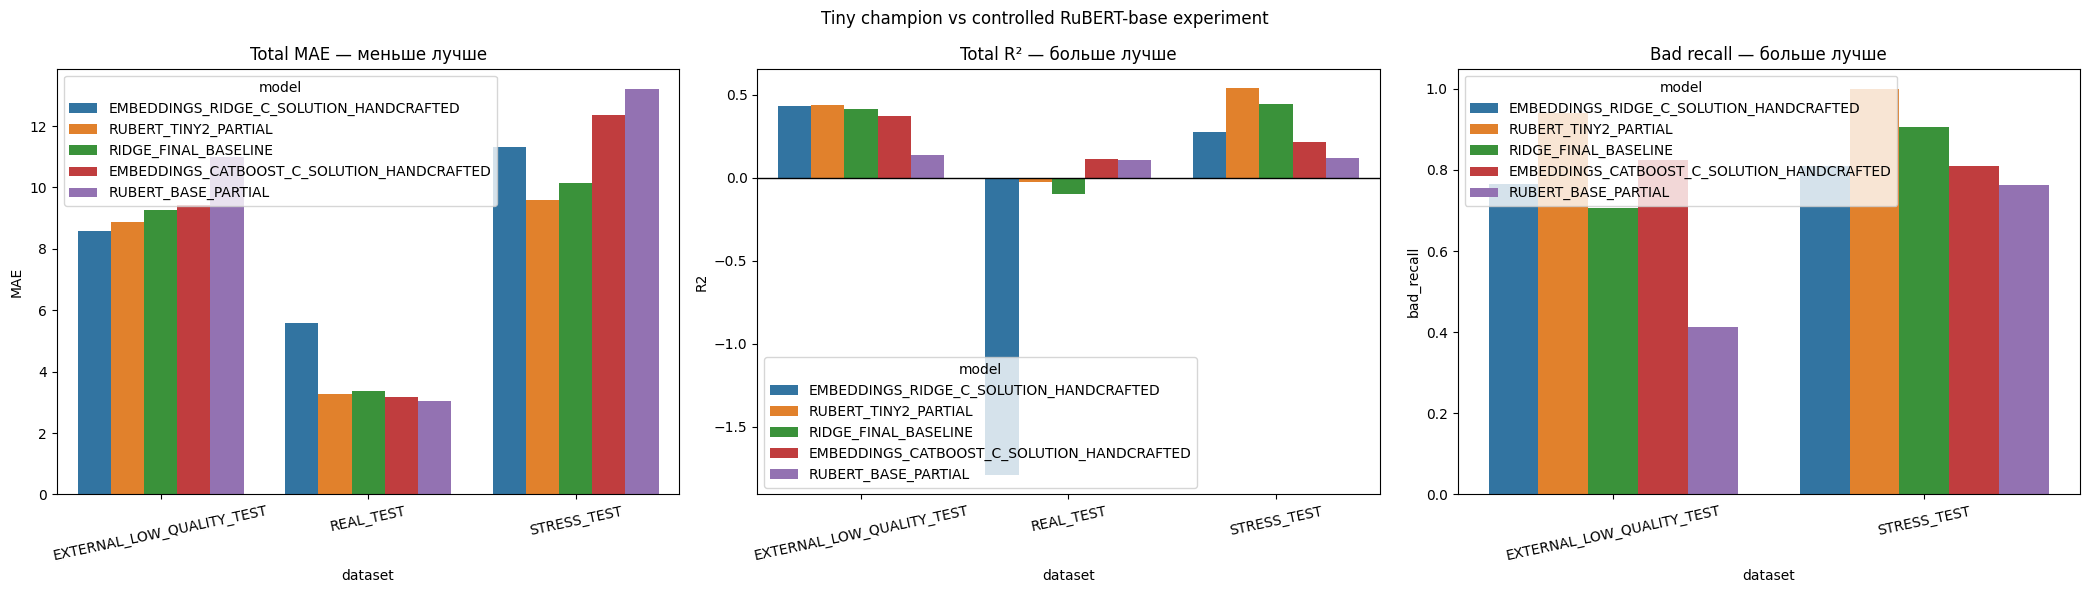

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sns.barplot(data=transformer_total_comparison_df, x='dataset', y='MAE', hue='model', ax=axes[0])
axes[0].set_title('Total MAE - меньше лучше')
sns.barplot(data=transformer_total_comparison_df, x='dataset', y='R2', hue='model', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Total R² - больше лучше')
sns.barplot(data=transformer_total_comparison_df.dropna(subset=['bad_recall']), x='dataset', y='bad_recall', hue='model', ax=axes[2])
axes[2].set_ylim(0, 1.05)
axes[2].set_title('Bad recall - больше лучше')
for ax in axes:
    ax.tick_params(axis='x', rotation=12)
fig.suptitle('Tiny champion vs controlled RuBERT-base experiment')
fig.tight_layout()
fig.savefig(TRANSFORMER_DIR / 'model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

In [ ]:
transformer_total_comparison_df.to_csv(
    TRANSFORMER_DIR / 'model_comparison.csv', index=False
)


## Вывод

PARTIAL оказался лучше FROZEN на validation. RuBERT-base улучшил REAL_TEST MAE до 3,0507, но хуже справился со слабыми решениями.

- STRESS_TEST: MAE 13,2129, bad recall 0,7619.
- EXTERNAL_LOW_QUALITY_TEST: MAE 11,0038, bad recall 0,4118.

Более крупная модель точнее оценивает обычные решения, но заметно хуже переносится на stress- и external-наборы. Поэтому RuBERT-tiny2 остаётся основной моделью.

RuBERT-base точнее на обычной тестовой выборке: MAE снизился с 3,2893 до 3,0507. На сложных данных результат ухудшился: stress MAE вырос до 13,2129, external MAE - до 11,0038, а external bad recall снизился до 0,4118. Для этого объёма данных RuBERT-tiny2 даёт более устойчивый результат и остаётся основной моделью